# K-Nearest Neighbor

### What is KNN?
- **Simple**: Easy to understand and implement.
- **Non-parametric**: Makes no assumptions about the underlying data distribution.
- **Lazy learning algorithm**: Does not require any training phase; it memorizes the entire training dataset.

- Used for both classification and regression.
- Classifies a data point based on majority class among its K nearest neighbors. 

### Why learn KNN?
- **Foundational algorithm**: The simplest distance-based algorithm for understanding spatial relationships in data.
- **Geometric Intuition**: Builds essential spatial reasoning skills for more complex ML methods
- **Baseline Model**: Provides a strong reference point for evaluating more complex algorithms.
- **Preprocessing Lessons**: Reveals why feature scaling and data preprocessing matter critically.

### What makes KNN special?
- No training phase 
- Stores all data
- Prediction based on proximity to neighbors

## Theory 

### Core Idea:
- KNN classifies a data point based on the majority class among its K nearest neighbors in the feature space.
- The "nearest" neighbors are determined using a distance metric, commonly Euclidean distance.
- The choice of K (number of neighbors) and the distance metric can significantly impact the performance of the algorithm.

### KNN for classification:
1. Choose the number of neighbors K.
2. For a new data point, calculate the distance to all training data points.
3. Identify the K nearest neighbors based on the calculated distances.
4. Assign the class label that is most common among the K nearest neighbors to the new data point.
5. Optionally, use distance-weighted voting where closer neighbors have more influence on the classification. 

### KNN for regression: 
1. Choose the number of neighbors K.
2. For a new data point, calculate the distance to all training data points.
3. Identify the K nearest neighbors based on the calculated distances.
4. Predict the value for the new data point by averaging the target values of the K nearest neighbors, optionally using distance-weighted averaging.
5. The predicted value is a continuous output, making KNN suitable for regression tasks as well.

> **Note**: KNN does not work well with high-dimensional data. Also it does not perform well with regression tasks when the data is noisy or has outliers.

### Distance Metrics:
- **Euclidean Distance**: The straight-line distance between two points in the feature space.
- **Manhattan Distance**: The sum of the absolute differences of their coordinates.
- **Minkowski Distance**: A generalization of both Euclidean and Manhattan distances, defined as the p-th root of the sum of the absolute differences raised to the power of p.

# Euclidean Distance:

Formula: 

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

# Manhattan Distance:

Formula:

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

# Minkowski Distance:

Formula:

$$d(x, y) = \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}$$

Where, 
$p$ = 1 corresponds to Manhattan distance, and $p$ = 2 corresponds to Euclidean distance.


When, P = 1, 
$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

When, P = 2,
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$


# Cosine Similarity:

Cosine Similarity measures the cosine of the angle between two vectors in a multi-dimensional space. It is commonly used in text analysis and natural language processing to measure the similarity between documents.

Formula: 
$$\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

Where,
- $A \cdot B$ is the dot product of vectors A and B.
- $\|A\|$ is the magnitude (length) of vector A.
- $\|B\|$ is the magnitude (length) of vector B.

# Choosing the value of K:
- **Cross-validation**: Use techniques like k-fold cross-validation to evaluate the performance of KNN with different values of K and select the one that gives the best performance.
- **Elbow Method**: Plot the error rate for different values of K and look for the "elbow" point where the error rate starts to decrease more slowly, indicating a good choice for K.
- **Domain Knowledge**: Consider the specific problem and dataset characteristics to choose an appropriate value of K. For example, in a dataset with a lot of noise, a larger K may help to smooth out the predictions.

**Small K:**
- Leads to overfitting.
- Sensitive to noise in the data.
- May not generalize well to unseen data.

**Large K:**
- Leads to underfitting.
- May smooth out the decision boundary too much.
- May not capture the local structure of the data effectively.

$$ K = \sqrt{N} $$

Where, $N$ is the number of samples in the training dataset. This is a common heuristic for choosing $K$, but it may not always be optimal. It is important to experiment with different values of $K$ and evaluate the performance of the model to find the best choice for a specific dataset.      

# What is K in K-Nearest Neighbor?
- K is the number of nearest neighbors to consider when making a prediction for a new data point.
- The choice of K can significantly impact the performance of the KNN algorithm. A small K may lead to overfitting, while a large K may lead to underfitting. It is important to experiment with different values of K and evaluate the model's performance to find the optimal K for a given dataset. 

# Values of K:
- **Small K**:
  - Leads to overfitting.4
  - Sensitive to noise in the data.
  - May not generalize well to unseen data.
- **Large K**:
  - Leads to underfitting.
  - Noise Resistant: A larger K can help to smooth out the predictions and reduce the impact of noise in the data.
  - May smooth out the decision boundary too much.
  - May not capture the local structure of the data effectively.

- **Optimal K**:
  - Sweet spot between overfitting and underfitting.
  - Determined through experimentation and evaluation on the specific dataset. 
  

# Starting Point: Rule of Thumb: 
$$ K = \sqrt{N} $$

Where, $N$ is the number of samples in the training dataset. This is a common heuristic for choosing $K$, but it may not always be optimal. It is important to experiment with different values of $K$ and evaluate the performance of the model to find the best choice for a specific dataset.  

**Odd K:** It is generally recommended to choose an odd value for $K$ to avoid ties in the voting process.

# Implementation:

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    accuracy_score
)


np.random.seed(42)

# 1) Training & Prediction Phase:

### What "training" means in KNN 
**KNN** is called a **lazy learner** because it does not learn weights of co-efficients.

In practice, `.fit()` does two important things:
- Fits the scaler on training data (learns mean and standard deviation)
- Stores the training data (this is what makes KNN a lazy learner)

So, training is fast, but prediction can be expensive/slow. 

### What prediction means: 

During `.predict()`, KNN does:
1. Compute distance from query point to all training points.
2. Sort distances and determine nearest neighbors based on K.
3. Select K nearest neighbors
4. Majority vote for the predicted class.

That is why KNN can become slow when the dataset is large. 

## Why scaling is non-negotiable

**KNN** uses distance. Distance is scale-sensitive. 

If one feauture has a much larger range than others, it dominates distance and breaks neight selection. 

So, we always place `StandardScaler` before KNN in the pipeline.

# 2) Implementing KNN on Dataset: 

We use the **Wine dataset** (3 classes). it is good for learning because: 
- all features are numeric
- multi-class classfication feels realistic.
- scalling matters
  
Pipeline we follow: 
1. Train test split
2. Pipeline = scaling + KNN
3. Fit on Training data
4. Predict on Test data
5. Evaluate performance (accuracy, confusion matrix, classification report)

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
print("classes:", list(wine.target_names))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)



Dataset shape: (178, 13)
classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [5]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [6]:
# Classification report and accuracy
print("accuracy_score:", float(accuracy_score(y_test, y_pred)))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=wine.target_names))

accuracy_score: 0.9777777777777777
Confusion Matrix:
 [[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



# 3) Model Evaluation and Optimization:

In [13]:
# Tuning K value
k_values = range(1, 42)
acc = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

In [14]:
print(acc)

[0.9555555555555556, 0.9333333333333333, 0.9555555555555556, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9777777777777777, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 1.0, 0.9777777777777777, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9777777777777777, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333]


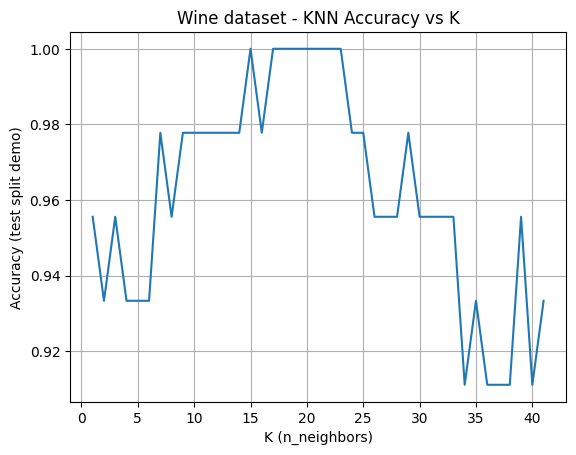

Best K value: 15 with accuracy: 1.0


In [17]:
plt.figure()
plt.plot(list(k_values), acc)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy (test split demo)")
plt.title("Wine dataset - KNN Accuracy vs K")
plt.grid(True)
plt.show()


best_k = list(k_values)[int(np.argmax(acc))]
print(f"Best K value: {best_k} with accuracy: {max(acc)}")

# Comparing distance metrics and voting weights:

In [18]:
k_demo = best_k

settings = [
    ("Euclidean (p = 2), uniform", KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p=2, weights='uniform')),
    ("Euclidean (p = 2), distance", KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p=2, weights='distance')),
    ("Manhattan (p = 1), uniform", KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p=1, weights='uniform')),
    ("Manhattan (p = 1), distance", KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p=1, weights='distance'))
]

rows = []

for name, knn in settings: 
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', knn)
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_score = accuracy_score(y_test, pred)
    
    rows.append([name, acc_score])
    
    
pd.DataFrame(rows, columns=["Setting", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Setting,Accuracy
0,"Euclidean (p = 2), uniform",1.000000
1,"Euclidean (p = 2), distance",1.000000
2,"Manhattan (p = 1), uniform",0.977778
3,"Manhattan (p = 1), distance",0.977778


In [19]:
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k)
knn_no_scale.fit(X_train, y_train)
pred_no_scale = knn_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, pred_no_scale)


pred_scale = clf.predict(X_test)
acc_scale = accuracy_score(y_test, pred_scale)

print(f"Accuracy without scaling: {acc_no_scale}"
      f"\nAccuracy with scaling: {acc_scale}")



Accuracy without scaling: 0.7777777777777778
Accuracy with scaling: 0.9777777777777777
